<a href="https://colab.research.google.com/github/Pranav-Trivedi20/Crop-classification-Model-using-Jetson-Xavier-mounted-on-UAV/blob/main/Crop_classification_Dataset_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras.applications.convnext import preprocess_input

In [ ]:
# Fix dtype mismatch in ConvNeXt
tf.keras.mixed_precision.set_global_policy('float32')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzip the dataset into Colab's temporary session storage
!unzip "/content/drive/MyDrive/Datasets/Agriculture crop images.zip"


Archive:  /content/drive/MyDrive/Datasets/Agriculture crop images.zip
  inflating: Crop_details.csv        
  inflating: crop_images/jute/jute001a.jpeg  
  inflating: crop_images/jute/jute002a.jpeg  
  inflating: crop_images/jute/jute003a.jpeg  
  inflating: crop_images/jute/jute004a.jpeg  
  inflating: crop_images/jute/jute006a.jpeg  
  inflating: crop_images/jute/jute007a.jpeg  
  inflating: crop_images/jute/jute008a.jpeg  
  inflating: crop_images/jute/jute009a.jpeg  
  inflating: crop_images/jute/jute010a.jpeg  
  inflating: crop_images/jute/jute013a.jpeg  
  inflating: crop_images/jute/jute014a.jpeg  
  inflating: crop_images/jute/jute015a.jpeg  
  inflating: crop_images/jute/jute016a.jpeg  
  inflating: crop_images/jute/jute017a.jpeg  
  inflating: crop_images/jute/jute018a.jpeg  
  inflating: crop_images/jute/jute019a.jpeg  
  inflating: crop_images/jute/jute020a.jpeg  
  inflating: crop_images/jute/jute021a.jpeg  
  inflating: crop_images/jute/jute022a.jpeg  
  inflating: crop_

In [ ]:
!ls "/content/drive/MyDrive/Datasets/Agriculture crop images.zip"

'/content/drive/MyDrive/Datasets/Agriculture crop images.zip'


In [ ]:
# === Config ===
data_dir_train = "/content/kag2"
data_dir_test = "/content/crop_images"

img_size = (224, 224)
batch_size = 16
num_classes = 5
epochs = 20

Found 544 images belonging to 5 classes.
Found 135 images belonging to 5 classes.
Found 175 images belonging to 5 classes.
Input: (None, 224, 224, 3)
ConvNeXtTiny output: (None, 7, 7, 768)
After SE Block: (None, 7, 7, 768)
After Resize: (None, 7, 7, 3)
After Conv2D (to 768): (None, 7, 7, 768)
After Self-Attention Block: (None, 7, 7, 768)
After Fusion (Add): (None, 7, 7, 768)
After GlobalAveragePooling: (None, 768)
After Dense(256): (None, 256)
Final Output (Softmax): (None, 5)


Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_24      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny       │ (None, 7, 7, 768) │ 27,820,128 │ input_layer_24[0… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 768)       │          0 │ convnext_tiny[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_4          │ (None, 7, 7, 3)   │          0 │ input_layer_24[0… │
│ (Resizing)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 48)        │     36,912 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 7, 7, 768) │      3,072 │ resizing_4[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 768)       │     37,632 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 7, 768) │      1,536 │ conv2d_4[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 1, 1, 768) │          0 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 7, 7, 768) │    394,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 7, 7, 768) │          0 │ convnext_tiny[0]… │
│ (Multiply)          │                   │            │ reshape_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_98 (Add)        │ (None, 7, 7, 768) │          0 │ conv2d_4[0][0],   │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_99 (Add)        │ (None, 7, 7, 768) │          0 │ multiply_4[0][0], │
│                     │                   │            │ add_98[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 768)       │          0 │ add_99[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 256)       │    196,864 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 5)         │      1,285 │ dense_18[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 28,491,797 (108.69 MB)

 Trainable params: 671,669 (2.56 MB)

 Non-trainable params: 27,820,128 (106.13 MB)

Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 40s 591ms/step - accuracy: 0.2941 - auc_4: 0.5899 - loss: 12.9440 - val_accuracy: 0.2074 - val_auc_4: 0.5681 - val_loss: 7.5116 - learning_rate: 0.0010
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 307ms/step - accuracy: 0.3327 - auc_4: 0.6234 - loss: 4.5422 - val_accuracy: 0.4444 - val_auc_4: 0.7614 - val_loss: 2.5506 - learning_rate: 0.0010
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 278ms/step - accuracy: 0.4136 - auc_4: 0.7175 - loss: 1.9707 - val_accuracy: 0.3778 - val_auc_4: 0.7263 - val_loss: 2.4474 - learning_rate: 0.0010
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 278ms/step - accuracy: 0.4026 - auc_4: 0.6848 - loss: 2.5220 - val_accuracy: 0.4222 - val_auc_4: 0.7994 - val_loss: 2.0704 - learning_rate: 0.0010
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 306ms/step - accuracy: 0.4908 - auc_4: 0.7808 - loss: 1.6188 - val_accuracy: 0.2889 - val_auc_4: 0.7896 - val_loss: 2.3428 - learning_rate: 0.0010
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 306ms/step - 

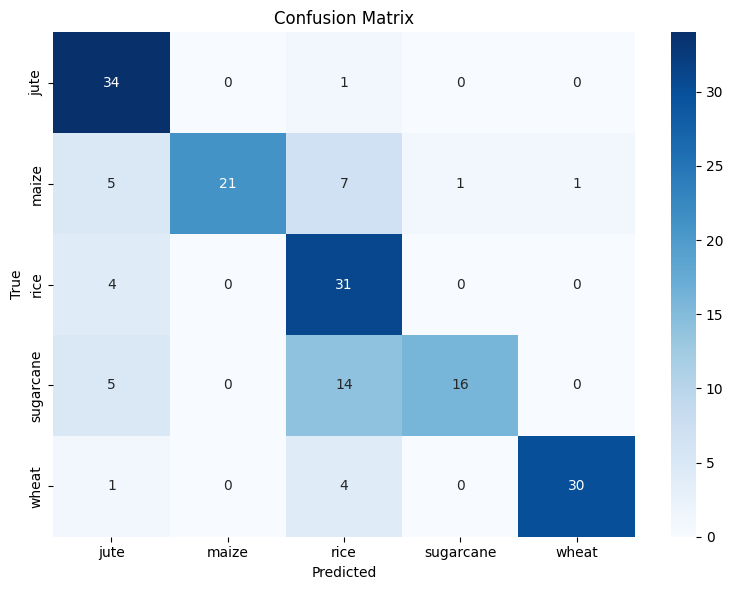

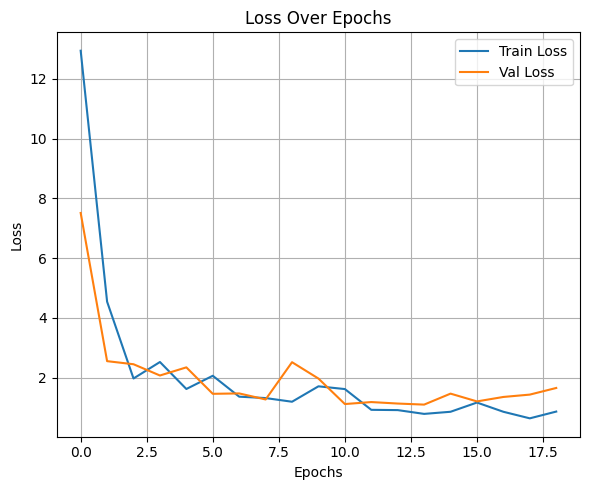

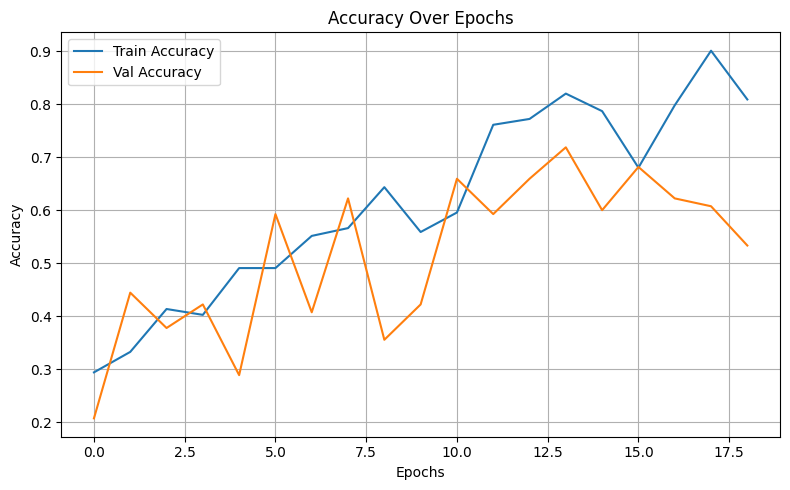

11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 672ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


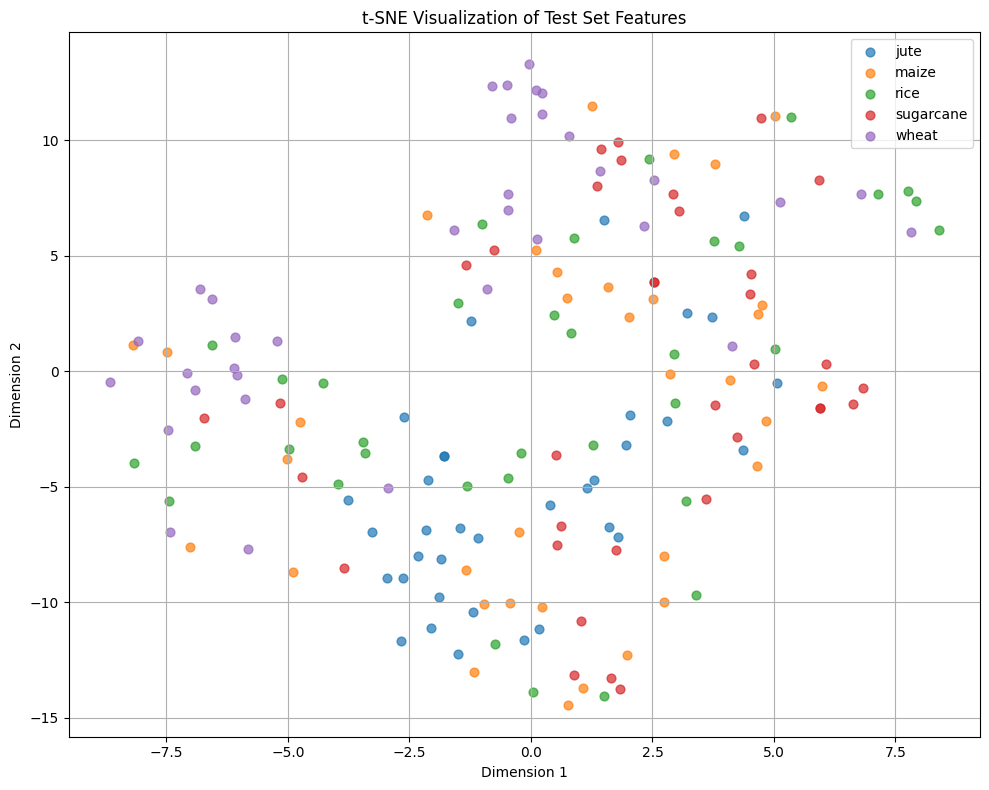

In [ ]:

# === Data Loaders ===
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    data_dir_train, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', subset='training'
)
val_generator = train_datagen.flow_from_directory(
    data_dir_train, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', subset='validation'
)
test_generator = test_datagen.flow_from_directory(
    data_dir_test, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', shuffle=False
)

# === SE Block ===
def se_block(inputs, reduction=16):
    channels = inputs.shape[-1]
    x = tf.keras.layers.GlobalAveragePooling2D()(inputs)
    x = tf.keras.layers.Dense(channels // reduction, activation='relu')(x)
    x = tf.keras.layers.Dense(channels, activation='sigmoid')(x)
    x = tf.keras.layers.Reshape((1, 1, channels))(x)
    return tf.keras.layers.Multiply()([inputs, x])

# === Self-Attention Block ===
def self_attention_block(inputs, num_heads=4, key_dim=32):
    x = tf.keras.layers.LayerNormalization()(inputs)
    x = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    x = tf.keras.layers.Add()([inputs, x])  # Residual connection
    return x

# === Model Definition ===
def create_convnext_tiny_with_attention(input_shape=(224, 224, 3), num_classes=5):
    inputs = tf.keras.Input(shape=input_shape)
    print("Input:", inputs.shape)

    # ConvNeXtTiny
    convnext = ConvNeXtTiny(include_top=False, weights='imagenet', input_shape=input_shape)
    convnext.trainable = False
    x1 = convnext(inputs, training=False)
    print("ConvNeXtTiny output:", x1.shape)

    # SE Block
    x1 = se_block(x1)
    print("After SE Block:", x1.shape)

    # Self-Attention Block
    x2 = tf.keras.layers.Resizing(7, 7)(inputs)
    print("After Resize:", x2.shape)

    x2 = tf.keras.layers.Conv2D(768, kernel_size=1)(x2)
    print("After Conv2D (to 768):", x2.shape)

    x2 = self_attention_block(x2)
    print("After Self-Attention Block:", x2.shape)

    # Fusion
    x = tf.keras.layers.Add()([x1, x2])
    print("After Fusion (Add):", x.shape)

    # Classification Head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    print("After GlobalAveragePooling:", x.shape)

    x = tf.keras.layers.Dense(256, activation='gelu')(x)
    print("After Dense(256):", x.shape)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    print("Final Output (Softmax):", outputs.shape)

    return tf.keras.Model(inputs, outputs)

# === Build Model ===
model = create_convnext_tiny_with_attention(input_shape=(224, 224, 3), num_classes=num_classes)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.AUC(multi_label=True, num_labels=num_classes)]
)

model.summary()

# === Training ===
early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1)
lr_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.0001, verbose=1)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[early_stopping, lr_callback]
)

# === Evaluation ===
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

# === Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# === Training Graphs ===
def smooth_curve(points, factor=0.8):
    smoothed = []
    for point in points:
        if smoothed:
            smoothed.append(smoothed[-1] * factor + point * (1 - factor))
        else:
            smoothed.append(point)
    return smoothed

plt.figure(figsize=(6, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === t-SNE Visualization (optional for feature insight) ===
from sklearn.manifold import TSNE
feature_extractor = tf.keras.Model(inputs=model.input, outputs=model.layers[-3].output)
features = feature_extractor.predict(test_generator, verbose=1)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
features_2d = tsne.fit_transform(features)
labels = y_true

plt.figure(figsize=(10, 8))
palette = sns.color_palette("hsv", num_classes)
for i, class_name in enumerate(class_names):
    idx = np.where(labels == i)
    plt.scatter(features_2d[idx, 0], features_2d[idx, 1], label=class_name, alpha=0.7, s=40)
plt.title("t-SNE Visualization of Test Set Features")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# this Tsne graph shows that data is difficult to separate.

# Now decreasing learning rate , epoch=50


Found 544 images belonging to 5 classes.
Found 135 images belonging to 5 classes.
Found 175 images belonging to 5 classes.
Input: (None, 224, 224, 3)
ConvNeXtTiny output: (None, 7, 7, 768)
After SE Block: (None, 7, 7, 768)
After Resize: (None, 7, 7, 3)
After Conv2D (to 768): (None, 7, 7, 768)
After Self-Attention Block: (None, 7, 7, 768)
After Fusion (Add): (None, 7, 7, 768)
After GlobalAveragePooling: (None, 768)
After Dense(256): (None, 256)
Final Output (Softmax): (None, 5)


Model: "functional_33"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_30      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny       │ (None, 7, 7, 768) │ 27,820,128 │ input_layer_30[0… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 768)       │          0 │ convnext_tiny[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_5          │ (None, 7, 7, 3)   │          0 │ input_layer_30[0… │
│ (Resizing)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 48)        │     36,912 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 7, 7, 768) │      3,072 │ resizing_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 768)       │     37,632 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 7, 768) │      1,536 │ conv2d_5[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 1, 1, 768) │          0 │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 7, 7, 768) │    394,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_5          │ (None, 7, 7, 768) │          0 │ convnext_tiny[0]… │
│ (Multiply)          │                   │            │ reshape_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_118 (Add)       │ (None, 7, 7, 768) │          0 │ conv2d_5[0][0],   │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_119 (Add)       │ (None, 7, 7, 768) │          0 │ multiply_5[0][0], │
│                     │                   │            │ add_118[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 768)       │          0 │ add_119[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 256)       │    196,864 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 5)         │      1,285 │ dense_22[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 28,491,797 (108.69 MB)

 Trainable params: 671,669 (2.56 MB)

 Non-trainable params: 27,820,128 (106.13 MB)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 40s 584ms/step - accuracy: 0.2702 - auc_5: 0.5904 - loss: 2.6224 - val_accuracy: 0.2741 - val_auc_5: 0.7014 - val_loss: 1.8014 - learning_rate: 1.0000e-04
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 298ms/step - accuracy: 0.3860 - auc_5: 0.7008 - loss: 1.5507 - val_accuracy: 0.3111 - val_auc_5: 0.7163 - val_loss: 1.5688 - learning_rate: 1.0000e-04
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 298ms/step - accuracy: 0.3860 - auc_5: 0.6862 - loss: 1.6158 - val_accuracy: 0.3481 - val_auc_5: 0.7368 - val_loss: 1.7126 - learning_rate: 1.0000e-04
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 368ms/step - accuracy: 0.3934 - auc_5: 0.7119 - loss: 1.5259 - val_accuracy: 0.3630 - val_auc_5: 0.7539 - val_loss: 1.6403 - learning_rate: 1.0000e-04
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 285ms/step - accuracy: 0.4467 - auc_5: 0.7416 - loss: 1.4361 - val_accuracy: 0.3111 - val_auc_5: 0.7290 - val_loss: 1.6967 - learning_rate: 1.0000e-04
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━

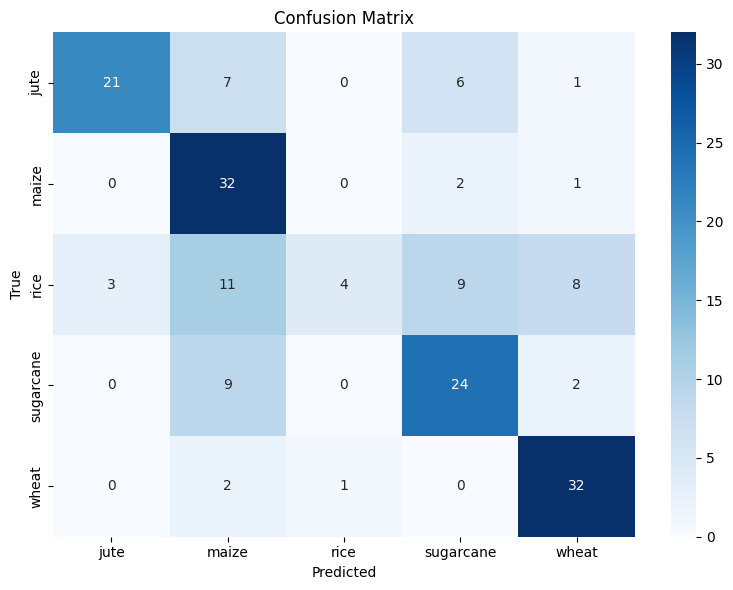

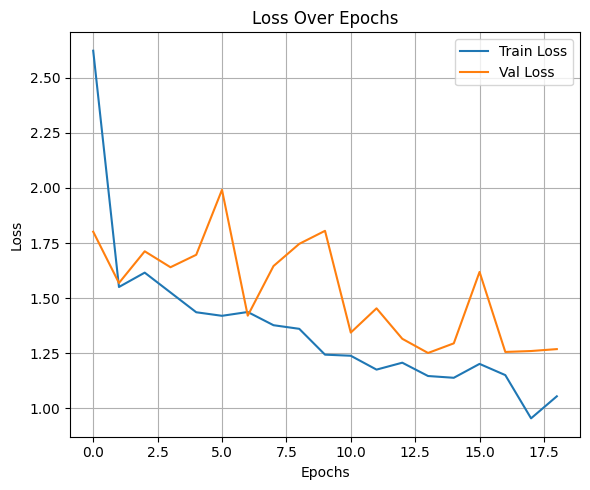

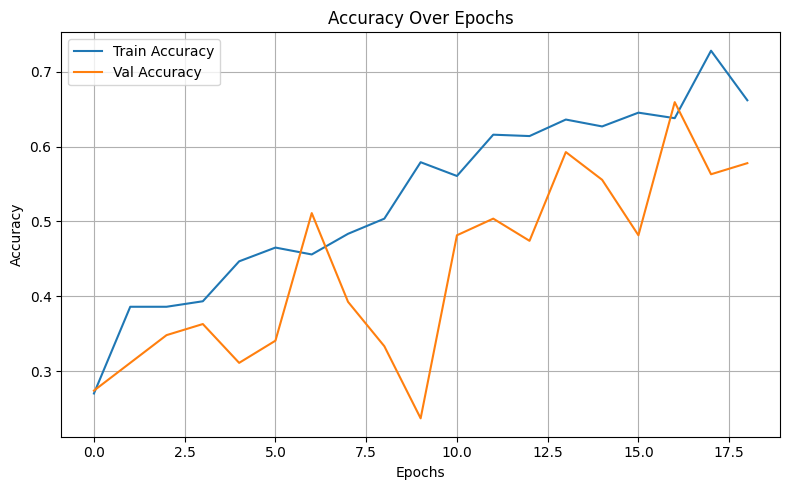

11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 542ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


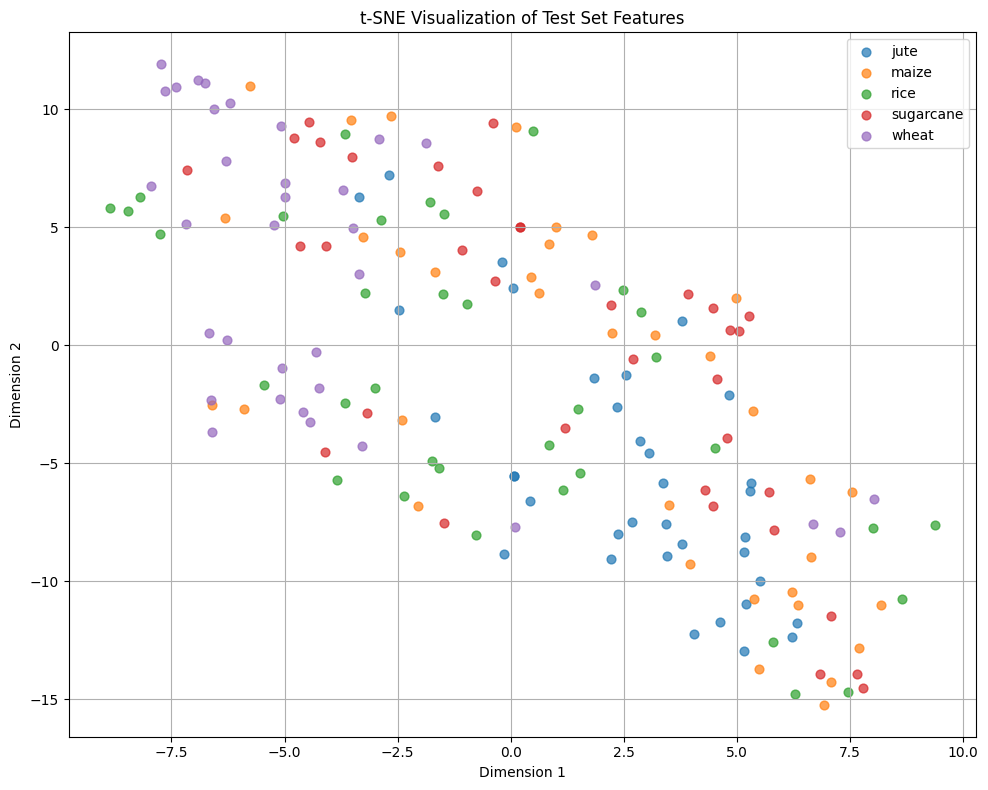

In [ ]:
# === Config ===
data_dir_train = "/content/kag2"
data_dir_test = "/content/crop_images"

img_size = (224, 224)
batch_size = 16
num_classes = 5
epochs = 50


# === Data Loaders ===
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    data_dir_train, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', subset='training'
)
val_generator = train_datagen.flow_from_directory(
    data_dir_train, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', subset='validation'
)
test_generator = test_datagen.flow_from_directory(
    data_dir_test, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', shuffle=False
)

# === SE Block ===
def se_block(inputs, reduction=16):
    channels = inputs.shape[-1]
    x = tf.keras.layers.GlobalAveragePooling2D()(inputs)
    x = tf.keras.layers.Dense(channels // reduction, activation='relu')(x)
    x = tf.keras.layers.Dense(channels, activation='sigmoid')(x)
    x = tf.keras.layers.Reshape((1, 1, channels))(x)
    return tf.keras.layers.Multiply()([inputs, x])

# === Self-Attention Block ===
def self_attention_block(inputs, num_heads=4, key_dim=32):
    x = tf.keras.layers.LayerNormalization()(inputs)
    x = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    x = tf.keras.layers.Add()([inputs, x])  # Residual connection
    return x

# === Model Definition ===
def create_convnext_tiny_with_attention(input_shape=(224, 224, 3), num_classes=5):
    inputs = tf.keras.Input(shape=input_shape)
    print("Input:", inputs.shape)

    # ConvNeXtTiny
    convnext = ConvNeXtTiny(include_top=False, weights='imagenet', input_shape=input_shape)
    convnext.trainable = False
    x1 = convnext(inputs, training=False)
    print("ConvNeXtTiny output:", x1.shape)

    # SE Block
    x1 = se_block(x1)
    print("After SE Block:", x1.shape)

    # Self-Attention Block
    x2 = tf.keras.layers.Resizing(7, 7)(inputs)
    print("After Resize:", x2.shape)

    x2 = tf.keras.layers.Conv2D(768, kernel_size=1)(x2)
    print("After Conv2D (to 768):", x2.shape)

    x2 = self_attention_block(x2)
    print("After Self-Attention Block:", x2.shape)

    # Fusion
    x = tf.keras.layers.Add()([x1, x2])
    print("After Fusion (Add):", x.shape)

    # Classification Head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    print("After GlobalAveragePooling:", x.shape)

    x = tf.keras.layers.Dense(256, activation='gelu')(x)
    print("After Dense(256):", x.shape)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    print("Final Output (Softmax):", outputs.shape)

    return tf.keras.Model(inputs, outputs)

# === Build Model ===
model = create_convnext_tiny_with_attention(input_shape=(224, 224, 3), num_classes=num_classes)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.AUC(multi_label=True, num_labels=num_classes)]
)

model.summary()

# === Training ===
early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1)
lr_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.0001, verbose=1)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[early_stopping, lr_callback]
)

# === Evaluation ===
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

# === Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# === Training Graphs ===
def smooth_curve(points, factor=0.8):
    smoothed = []
    for point in points:
        if smoothed:
            smoothed.append(smoothed[-1] * factor + point * (1 - factor))
        else:
            smoothed.append(point)
    return smoothed

plt.figure(figsize=(6, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === t-SNE Visualization (optional for feature insight) ===
from sklearn.manifold import TSNE
feature_extractor = tf.keras.Model(inputs=model.input, outputs=model.layers[-3].output)
features = feature_extractor.predict(test_generator, verbose=1)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
features_2d = tsne.fit_transform(features)
labels = y_true

plt.figure(figsize=(10, 8))
palette = sns.color_palette("hsv", num_classes)
for i, class_name in enumerate(class_names):
    idx = np.where(labels == i)
    plt.scatter(features_2d[idx, 0], features_2d[idx, 1], label=class_name, alpha=0.7, s=40)
plt.title("t-SNE Visualization of Test Set Features")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Now we are increasing the learning rate[learning_rate=0.002] , epoch=50

Found 544 images belonging to 5 classes.
Found 135 images belonging to 5 classes.
Found 175 images belonging to 5 classes.
Input: (None, 224, 224, 3)
ConvNeXtTiny output: (None, 7, 7, 768)
After SE Block: (None, 7, 7, 768)
After Resize: (None, 7, 7, 3)
After Conv2D (to 768): (None, 7, 7, 768)
After Self-Attention Block: (None, 7, 7, 768)
After Fusion (Add): (None, 7, 7, 768)
After GlobalAveragePooling: (None, 768)
After Dense(256): (None, 256)
Final Output (Softmax): (None, 5)


Model: "functional_39"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_36      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny       │ (None, 7, 7, 768) │ 27,820,128 │ input_layer_36[0… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 768)       │          0 │ convnext_tiny[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_6          │ (None, 7, 7, 3)   │          0 │ input_layer_36[0… │
│ (Resizing)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 48)        │     36,912 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 7, 7, 768) │      3,072 │ resizing_6[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 768)       │     37,632 │ dense_24[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 7, 768) │      1,536 │ conv2d_6[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_6 (Reshape) │ (None, 1, 1, 768) │          0 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 7, 7, 768) │    394,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_6          │ (None, 7, 7, 768) │          0 │ convnext_tiny[0]… │
│ (Multiply)          │                   │            │ reshape_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_138 (Add)       │ (None, 7, 7, 768) │          0 │ conv2d_6[0][0],   │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_139 (Add)       │ (None, 7, 7, 768) │          0 │ multiply_6[0][0], │
│                     │                   │            │ add_138[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 768)       │          0 │ add_139[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 256)       │    196,864 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 5)         │      1,285 │ dense_26[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 28,491,797 (108.69 MB)

 Trainable params: 671,669 (2.56 MB)

 Non-trainable params: 27,820,128 (106.13 MB)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 50s 635ms/step - accuracy: 0.2702 - auc_6: 0.5591 - loss: 20.8761 - val_accuracy: 0.3926 - val_auc_6: 0.6233 - val_loss: 5.9462 - learning_rate: 0.0020
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 305ms/step - accuracy: 0.3842 - auc_6: 0.6557 - loss: 2.9570 - val_accuracy: 0.3630 - val_auc_6: 0.7455 - val_loss: 1.8853 - learning_rate: 0.0020
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 276ms/step - accuracy: 0.4596 - auc_6: 0.7562 - loss: 1.6721 - val_accuracy: 0.2667 - val_auc_6: 0.7065 - val_loss: 3.0493 - learning_rate: 0.0020
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 272ms/step - accuracy: 0.5055 - auc_6: 0.7873 - loss: 1.5800 - val_accuracy: 0.5259 - val_auc_6: 0.8395 - val_loss: 1.5518 - learning_rate: 0.0020
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 302ms/step - accuracy: 0.5643 - auc_6: 0.8207 - loss: 1.3825 - val_accuracy: 0.2148 - val_auc_6: 0.7445 - val_loss: 3.3834 - learning_rate: 0.0020
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 313ms/step - a

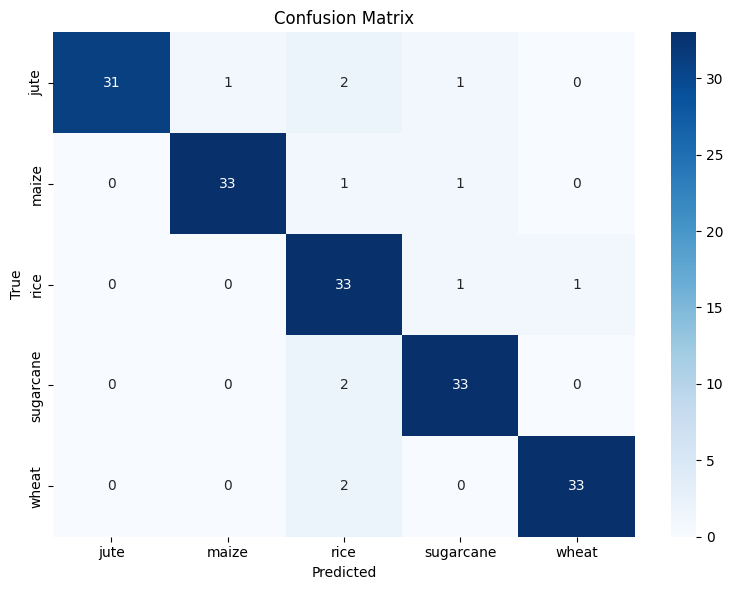

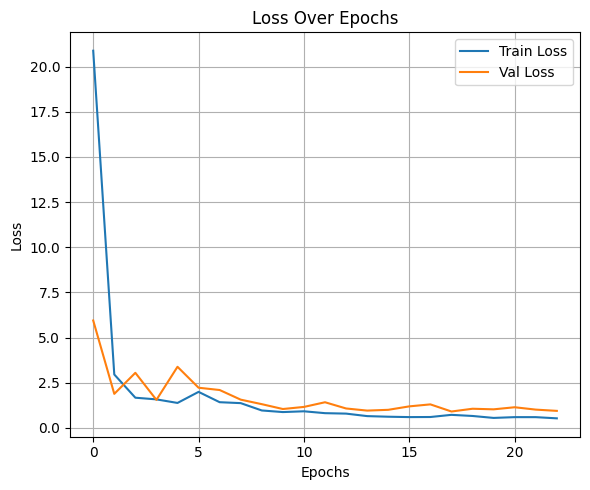

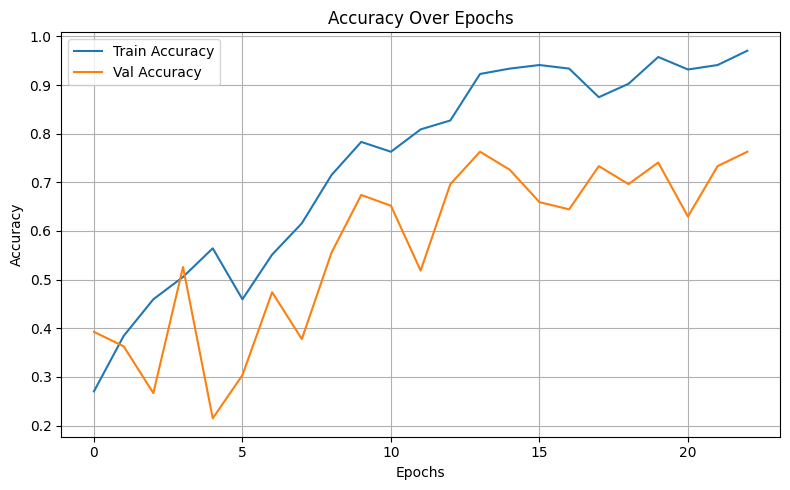

11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 549ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


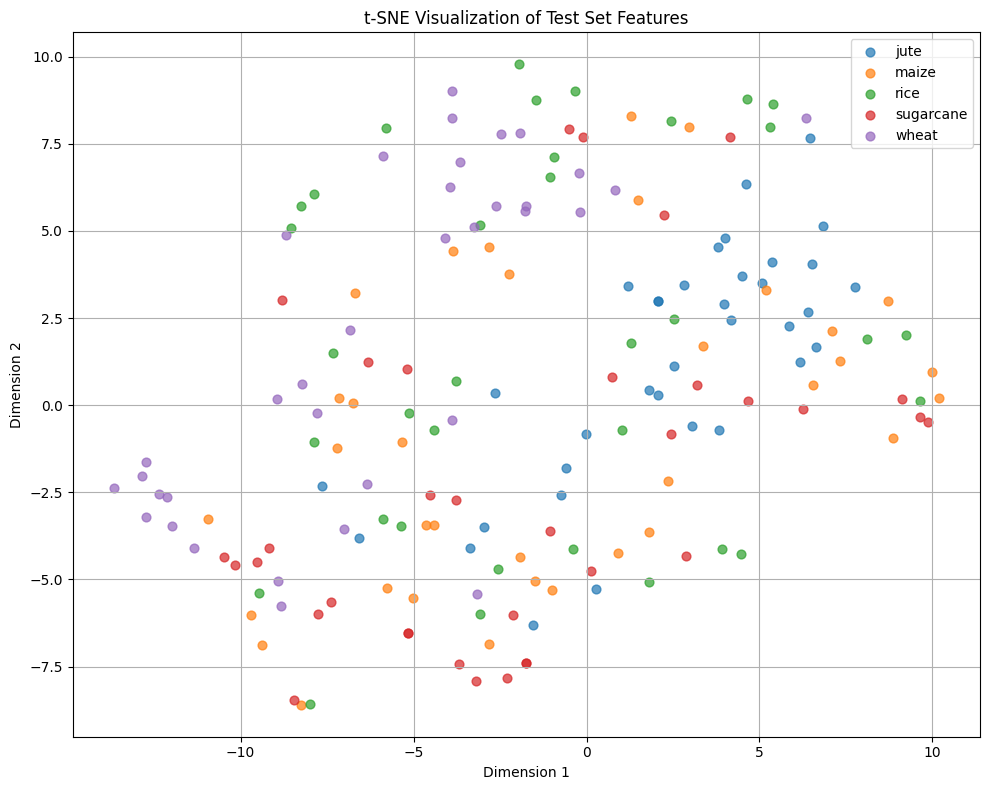

In [ ]:
# === Config ===
data_dir_train = "/content/kag2"
data_dir_test = "/content/crop_images"

img_size = (224, 224)
batch_size = 16
num_classes = 5
epochs = 50


# === Data Loaders ===
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    data_dir_train, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', subset='training'
)
val_generator = train_datagen.flow_from_directory(
    data_dir_train, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', subset='validation'
)
test_generator = test_datagen.flow_from_directory(
    data_dir_test, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', shuffle=False
)

# === SE Block ===
def se_block(inputs, reduction=16):
    channels = inputs.shape[-1]
    x = tf.keras.layers.GlobalAveragePooling2D()(inputs)
    x = tf.keras.layers.Dense(channels // reduction, activation='relu')(x)
    x = tf.keras.layers.Dense(channels, activation='sigmoid')(x)
    x = tf.keras.layers.Reshape((1, 1, channels))(x)
    return tf.keras.layers.Multiply()([inputs, x])

# === Self-Attention Block ===
def self_attention_block(inputs, num_heads=4, key_dim=32):
    x = tf.keras.layers.LayerNormalization()(inputs)
    x = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    x = tf.keras.layers.Add()([inputs, x])  # Residual connection
    return x

# === Model Definition ===
def create_convnext_tiny_with_attention(input_shape=(224, 224, 3), num_classes=5):
    inputs = tf.keras.Input(shape=input_shape)
    print("Input:", inputs.shape)

    # ConvNeXtTiny
    convnext = ConvNeXtTiny(include_top=False, weights='imagenet', input_shape=input_shape)
    convnext.trainable = False
    x1 = convnext(inputs, training=False)
    print("ConvNeXtTiny output:", x1.shape)

    # SE Block
    x1 = se_block(x1)
    print("After SE Block:", x1.shape)

    # Self-Attention Block
    x2 = tf.keras.layers.Resizing(7, 7)(inputs)
    print("After Resize:", x2.shape)

    x2 = tf.keras.layers.Conv2D(768, kernel_size=1)(x2)
    print("After Conv2D (to 768):", x2.shape)

    x2 = self_attention_block(x2)
    print("After Self-Attention Block:", x2.shape)

    # Fusion
    x = tf.keras.layers.Add()([x1, x2])
    print("After Fusion (Add):", x.shape)

    # Classification Head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    print("After GlobalAveragePooling:", x.shape)

    x = tf.keras.layers.Dense(256, activation='gelu')(x)
    print("After Dense(256):", x.shape)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    print("Final Output (Softmax):", outputs.shape)

    return tf.keras.Model(inputs, outputs)

# === Build Model ===
model = create_convnext_tiny_with_attention(input_shape=(224, 224, 3), num_classes=num_classes)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.AUC(multi_label=True, num_labels=num_classes)]
)

model.summary()

# === Training ===
early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1)
lr_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.0001, verbose=1)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[early_stopping, lr_callback]
)

# === Evaluation ===
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

# === Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# === Training Graphs ===
def smooth_curve(points, factor=0.8):
    smoothed = []
    for point in points:
        if smoothed:
            smoothed.append(smoothed[-1] * factor + point * (1 - factor))
        else:
            smoothed.append(point)
    return smoothed

plt.figure(figsize=(6, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === t-SNE Visualization (optional for feature insight) ===
from sklearn.manifold import TSNE
feature_extractor = tf.keras.Model(inputs=model.input, outputs=model.layers[-3].output)
features = feature_extractor.predict(test_generator, verbose=1)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
features_2d = tsne.fit_transform(features)
labels = y_true

plt.figure(figsize=(10, 8))
palette = sns.color_palette("hsv", num_classes)
for i, class_name in enumerate(class_names):
    idx = np.where(labels == i)
    plt.scatter(features_2d[idx, 0], features_2d[idx, 1], label=class_name, alpha=0.7, s=40)
plt.title("t-SNE Visualization of Test Set Features")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


##After increasing learning rate=0.02, Accuracy becomes=93.17%(excellent accuracy)

##Now increasing batch size=32

Found 544 images belonging to 5 classes.
Found 135 images belonging to 5 classes.
Found 175 images belonging to 5 classes.
Input: (None, 224, 224, 3)
ConvNeXtTiny output: (None, 7, 7, 768)
After SE Block: (None, 7, 7, 768)
After Resize: (None, 7, 7, 3)
After Conv2D (to 768): (None, 7, 7, 768)
After Self-Attention Block: (None, 7, 7, 768)
After Fusion (Add): (None, 7, 7, 768)
After GlobalAveragePooling: (None, 768)
After Dense(256): (None, 256)
Final Output (Softmax): (None, 5)


Model: "functional_45"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_42      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny       │ (None, 7, 7, 768) │ 27,820,128 │ input_layer_42[0… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 768)       │          0 │ convnext_tiny[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_7          │ (None, 7, 7, 3)   │          0 │ input_layer_42[0… │
│ (Resizing)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 48)        │     36,912 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 7, 7, 768) │      3,072 │ resizing_7[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 768)       │     37,632 │ dense_28[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 7, 768) │      1,536 │ conv2d_7[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_7 (Reshape) │ (None, 1, 1, 768) │          0 │ dense_29[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 7, 7, 768) │    394,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_7          │ (None, 7, 7, 768) │          0 │ convnext_tiny[0]… │
│ (Multiply)          │                   │            │ reshape_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_158 (Add)       │ (None, 7, 7, 768) │          0 │ conv2d_7[0][0],   │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_159 (Add)       │ (None, 7, 7, 768) │          0 │ multiply_7[0][0], │
│                     │                   │            │ add_158[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 768)       │          0 │ add_159[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 256)       │    196,864 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 5)         │      1,285 │ dense_30[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 28,491,797 (108.69 MB)

 Trainable params: 671,669 (2.56 MB)

 Non-trainable params: 27,820,128 (106.13 MB)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.1967 - auc_7: 0.5034 - loss: 32.2878 - val_accuracy: 0.3704 - val_auc_7: 0.6389 - val_loss: 11.9646 - learning_rate: 0.0020
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 544ms/step - accuracy: 0.2868 - auc_7: 0.5826 - loss: 9.5358 - val_accuracy: 0.3852 - val_auc_7: 0.6442 - val_loss: 6.6769 - learning_rate: 0.0020
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 551ms/step - accuracy: 0.3860 - auc_7: 0.6671 - loss: 2.8071 - val_accuracy: 0.3111 - val_auc_7: 0.6990 - val_loss: 3.5438 - learning_rate: 0.0020
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 603ms/step - accuracy: 0.4449 - auc_7: 0.7216 - loss: 1.9482 - val_accuracy: 0.3630 - val_auc_7: 0.7610 - val_loss: 1.7882 - learning_rate: 0.0020
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 718ms/step - accuracy: 0.5515 - auc_7: 0.8055 - loss: 1.3521 - val_accuracy: 0.4000 - val_auc_7: 0.8295 - val_loss: 1.4674 - learning_rate: 0.0020
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 497ms/step - acc

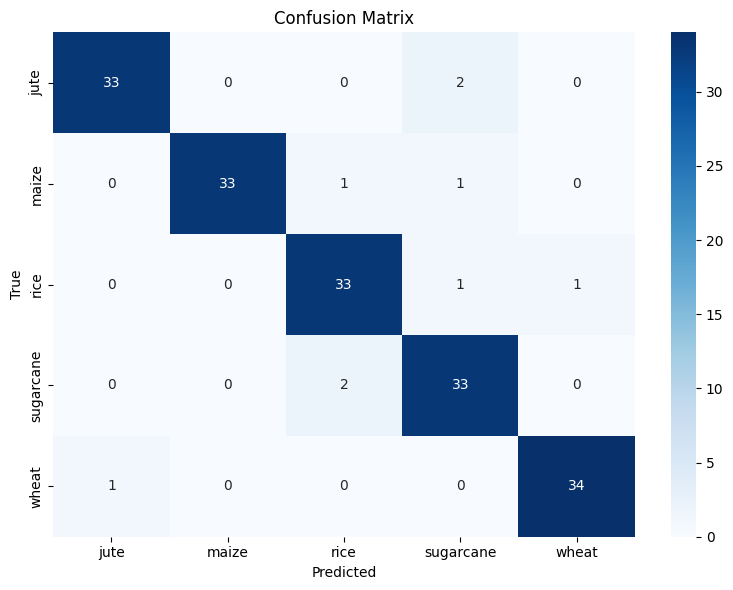

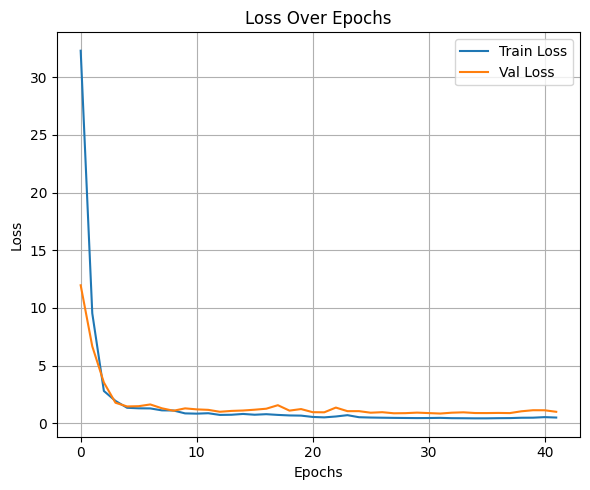

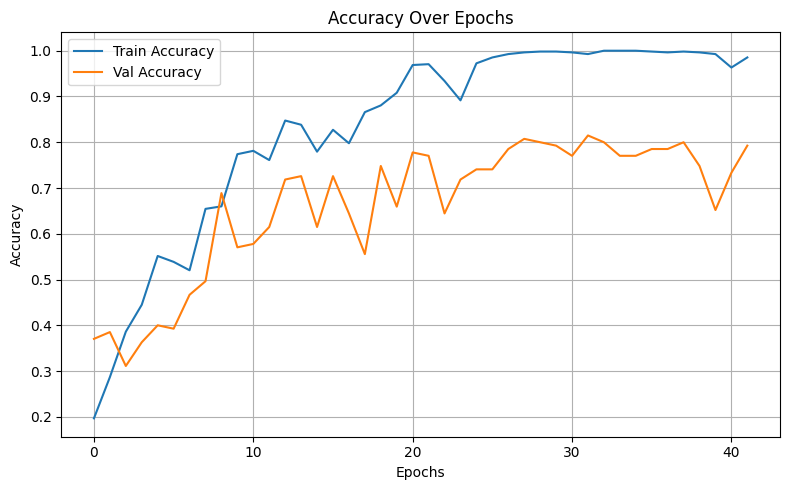

6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


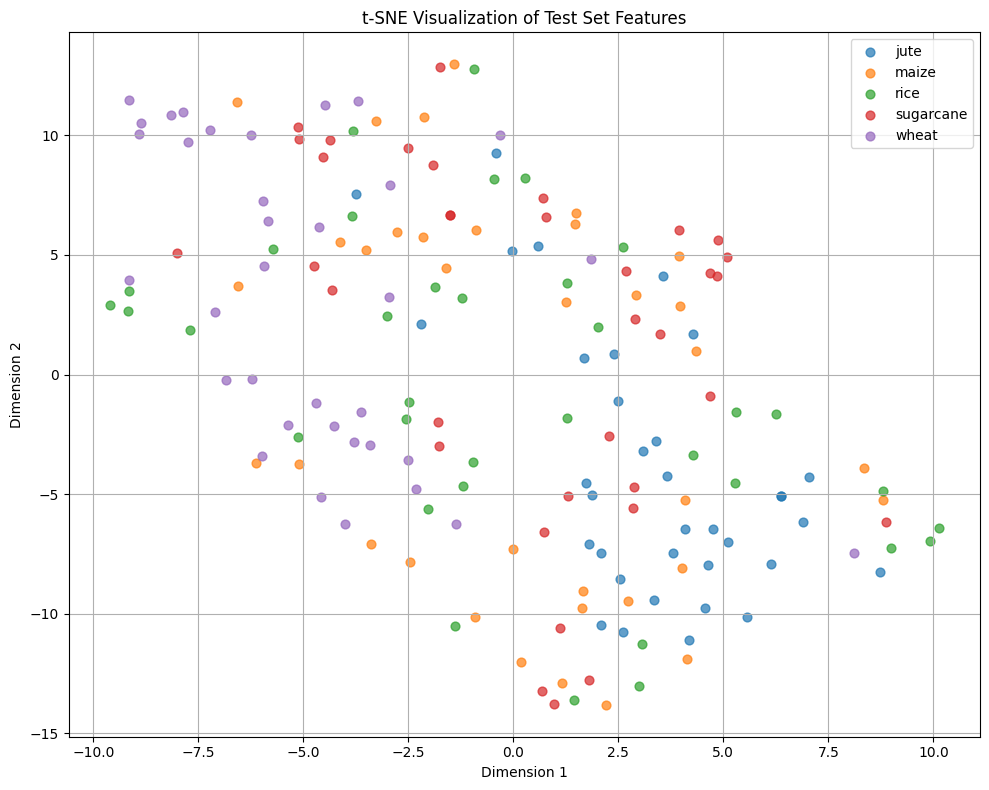

In [ ]:
# === Config ===
data_dir_train = "/content/kag2"
data_dir_test = "/content/crop_images"

img_size = (224, 224)
batch_size = 32
num_classes = 5
epochs = 50


# === Data Loaders ===
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    data_dir_train, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', subset='training'
)
val_generator = train_datagen.flow_from_directory(
    data_dir_train, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', subset='validation'
)
test_generator = test_datagen.flow_from_directory(
    data_dir_test, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', shuffle=False
)

# === SE Block ===
def se_block(inputs, reduction=16):
    channels = inputs.shape[-1]
    x = tf.keras.layers.GlobalAveragePooling2D()(inputs)
    x = tf.keras.layers.Dense(channels // reduction, activation='relu')(x)
    x = tf.keras.layers.Dense(channels, activation='sigmoid')(x)
    x = tf.keras.layers.Reshape((1, 1, channels))(x)
    return tf.keras.layers.Multiply()([inputs, x])

# === Self-Attention Block ===
def self_attention_block(inputs, num_heads=4, key_dim=32):
    x = tf.keras.layers.LayerNormalization()(inputs)
    x = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    x = tf.keras.layers.Add()([inputs, x])  # Residual connection
    return x

# === Model Definition ===
def create_convnext_tiny_with_attention(input_shape=(224, 224, 3), num_classes=5):
    inputs = tf.keras.Input(shape=input_shape)
    print("Input:", inputs.shape)

    # ConvNeXtTiny
    convnext = ConvNeXtTiny(include_top=False, weights='imagenet', input_shape=input_shape)
    convnext.trainable = False
    x1 = convnext(inputs, training=False)
    print("ConvNeXtTiny output:", x1.shape)

    # SE Block
    x1 = se_block(x1)
    print("After SE Block:", x1.shape)

    # Self-Attention Block
    x2 = tf.keras.layers.Resizing(7, 7)(inputs)
    print("After Resize:", x2.shape)

    x2 = tf.keras.layers.Conv2D(768, kernel_size=1)(x2)
    print("After Conv2D (to 768):", x2.shape)

    x2 = self_attention_block(x2)
    print("After Self-Attention Block:", x2.shape)

    # Fusion
    x = tf.keras.layers.Add()([x1, x2])
    print("After Fusion (Add):", x.shape)

    # Classification Head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    print("After GlobalAveragePooling:", x.shape)

    x = tf.keras.layers.Dense(256, activation='gelu')(x)
    print("After Dense(256):", x.shape)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    print("Final Output (Softmax):", outputs.shape)

    return tf.keras.Model(inputs, outputs)

# === Build Model ===
model = create_convnext_tiny_with_attention(input_shape=(224, 224, 3), num_classes=num_classes)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.AUC(multi_label=True, num_labels=num_classes)]
)

model.summary()

# === Training ===
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
lr_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.0001, verbose=1)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[early_stopping, lr_callback]
)

# === Evaluation ===
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

# === Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# === Training Graphs ===
def smooth_curve(points, factor=0.8):
    smoothed = []
    for point in points:
        if smoothed:
            smoothed.append(smoothed[-1] * factor + point * (1 - factor))
        else:
            smoothed.append(point)
    return smoothed

plt.figure(figsize=(6, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === t-SNE Visualization (optional for feature insight) ===
from sklearn.manifold import TSNE
feature_extractor = tf.keras.Model(inputs=model.input, outputs=model.layers[-3].output)
features = feature_extractor.predict(test_generator, verbose=1)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
features_2d = tsne.fit_transform(features)
labels = y_true

plt.figure(figsize=(10, 8))
palette = sns.color_palette("hsv", num_classes)
for i, class_name in enumerate(class_names):
    idx = np.where(labels == i)
    plt.scatter(features_2d[idx, 0], features_2d[idx, 1], label=class_name, alpha=0.7, s=40)
plt.title("t-SNE Visualization of Test Set Features")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Accuracy =94.86%, (batch size=32)

##Now "Fine-tune ConvNeXt" to imporve accuracy

Found 544 images belonging to 5 classes.
Found 135 images belonging to 5 classes.
Found 175 images belonging to 5 classes.
Input: (None, 224, 224, 3)
111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ConvNeXtTiny output: (None, 7, 7, 768)
After SE Block: (None, 7, 7, 768)
After Resize: (None, 7, 7, 3)
After Conv2D (to 768): (None, 7, 7, 768)
After Self-Attention Block: (None, 7, 7, 768)
After Fusion (Add): (None, 7, 7, 768)
After GlobalAveragePooling: (None, 768)
After Dense(256): (None, 256)
Final Output (Softmax): (None, 5)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny       │ (None, 7, 7, 768) │ 27,820,128 │ input_layer[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 768)       │          0 │ convnext_tiny[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 7, 7, 3)   │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 48)        │     36,912 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 7, 7, 768) │      3,072 │ resizing[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 768)       │     37,632 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 7, 768) │      1,536 │ conv2d[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 768) │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 7, 7, 768) │    394,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 7, 7, 768) │          0 │ convnext_tiny[0]… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 7, 7, 768) │          0 │ conv2d[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 7, 7, 768) │          0 │ multiply[0][0],   │
│                     │                   │            │ add_18[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 768)       │          0 │ add_19[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    196,864 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 5)         │      1,285 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 28,491,797 (108.69 MB)

 Trainable params: 17,345,717 (66.17 MB)

 Non-trainable params: 11,146,080 (42.52 MB)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.1324 - auc: 0.4549 - loss: 6.6596 - val_accuracy: 0.1852 - val_auc: 0.5091 - val_loss: 3.3586 - learning_rate: 1.0000e-05
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 639ms/step - accuracy: 0.2592 - auc: 0.4982 - loss: 2.4508 - val_accuracy: 0.2370 - val_auc: 0.5849 - val_loss: 2.2084 - learning_rate: 1.0000e-05
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 768ms/step - accuracy: 0.2776 - auc: 0.5794 - loss: 1.8329 - val_accuracy: 0.2074 - val_auc: 0.5770 - val_loss: 1.7165 - learning_rate: 1.0000e-05
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 747ms/step - accuracy: 0.3548 - auc: 0.6634 - loss: 1.5748 - val_accuracy: 0.4074 - val_auc: 0.6714 - val_loss: 1.5470 - learning_rate: 1.0000e-05
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 733ms/step - accuracy: 0.4467 - auc: 0.7405 - loss: 1.4419 - val_accuracy: 0.3778 - val_auc: 0.6821 - val_loss: 1.5112 - learning_rate: 1.0000e-05
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 753ms/step - acc

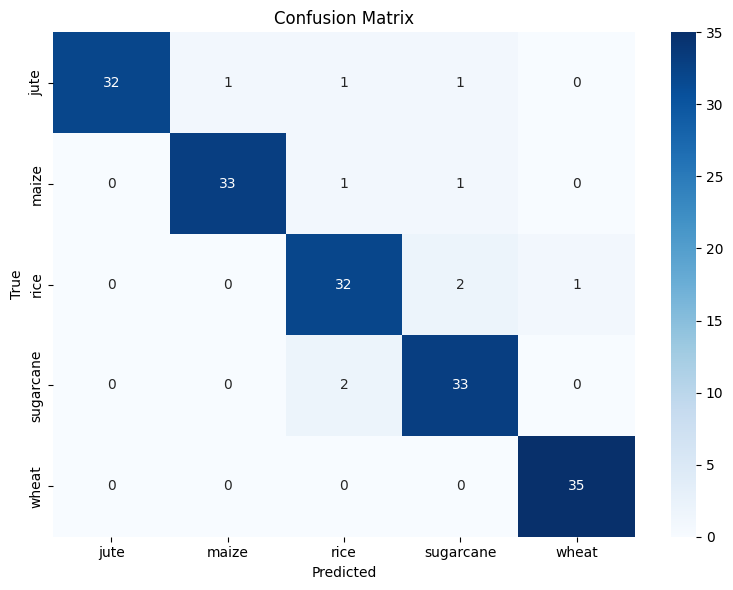

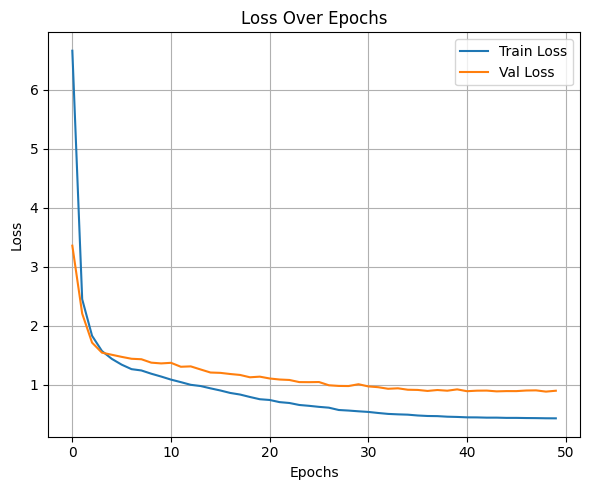

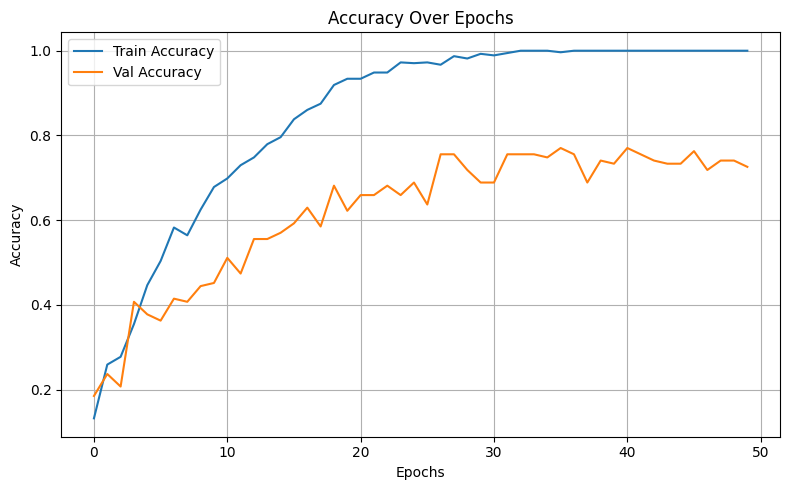

6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


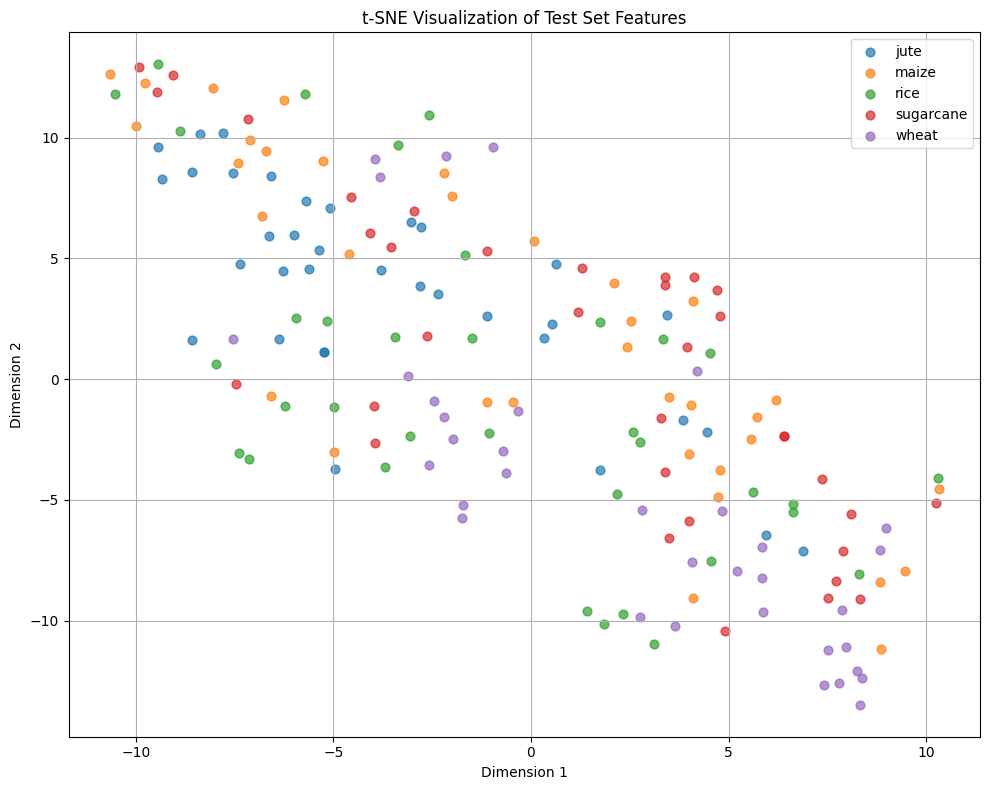

In [ ]:
# === Config ===
data_dir_train = "/content/kag2"
data_dir_test = "/content/crop_images"

img_size = (224, 224)
batch_size = 32
num_classes = 5
epochs = 50


# === Data Loaders ===
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    data_dir_train, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', subset='training'
)
val_generator = train_datagen.flow_from_directory(
    data_dir_train, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', subset='validation'
)
test_generator = test_datagen.flow_from_directory(
    data_dir_test, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', shuffle=False
)

# === SE Block ===
def se_block(inputs, reduction=16):
    channels = inputs.shape[-1]
    x = tf.keras.layers.GlobalAveragePooling2D()(inputs)
    x = tf.keras.layers.Dense(channels // reduction, activation='relu')(x)
    x = tf.keras.layers.Dense(channels, activation='sigmoid')(x)
    x = tf.keras.layers.Reshape((1, 1, channels))(x)
    return tf.keras.layers.Multiply()([inputs, x])

# === Self-Attention Block ===
def self_attention_block(inputs, num_heads=4, key_dim=32):
    x = tf.keras.layers.LayerNormalization()(inputs)
    x = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    x = tf.keras.layers.Add()([inputs, x])  # Residual connection
    return x

# === Model Definition ===
def create_convnext_tiny_with_attention(input_shape=(224, 224, 3), num_classes=5):
    inputs = tf.keras.Input(shape=input_shape)
    print("Input:", inputs.shape)

    # ConvNeXtTiny
    convnext = ConvNeXtTiny(include_top=False, weights='imagenet', input_shape=input_shape)

    # Freeze most layers
    convnext.trainable = True

    # Freeze all except the last 30 layers
    for layer in convnext.layers[:-30]:
        layer.trainable = False

    x1 = convnext(inputs, training=True)
    print("ConvNeXtTiny output:", x1.shape)

    # SE Block
    x1 = se_block(x1)
    print("After SE Block:", x1.shape)

    # Self-Attention Block
    x2 = tf.keras.layers.Resizing(7, 7)(inputs)
    print("After Resize:", x2.shape)

    x2 = tf.keras.layers.Conv2D(768, kernel_size=1)(x2)
    print("After Conv2D (to 768):", x2.shape)

    x2 = self_attention_block(x2)
    print("After Self-Attention Block:", x2.shape)

    # Fusion
    x = tf.keras.layers.Add()([x1, x2])
    print("After Fusion (Add):", x.shape)

    # Classification Head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    print("After GlobalAveragePooling:", x.shape)

    x = tf.keras.layers.Dense(256, activation='gelu')(x)
    print("After Dense(256):", x.shape)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    print("Final Output (Softmax):", outputs.shape)

    return tf.keras.Model(inputs, outputs)

# === Build Model ===
model = create_convnext_tiny_with_attention(input_shape=(224, 224, 3), num_classes=num_classes)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.AUC(multi_label=True, num_labels=num_classes)]
)

model.summary()

# === Training ===
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
lr_callback = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[early_stopping, lr_callback]
)

# === Evaluation ===
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

# === Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# === Training Graphs ===
def smooth_curve(points, factor=0.8):
    smoothed = []
    for point in points:
        if smoothed:
            smoothed.append(smoothed[-1] * factor + point * (1 - factor))
        else:
            smoothed.append(point)
    return smoothed

plt.figure(figsize=(6, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === t-SNE Visualization (optional for feature insight) ===
from sklearn.manifold import TSNE
feature_extractor = tf.keras.Model(inputs=model.input, outputs=model.layers[-3].output)
features = feature_extractor.predict(test_generator, verbose=1)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
features_2d = tsne.fit_transform(features)
labels = y_true

plt.figure(figsize=(10, 8))
palette = sns.color_palette("hsv", num_classes)
for i, class_name in enumerate(class_names):
    idx = np.where(labels == i)
    plt.scatter(features_2d[idx, 0], features_2d[idx, 1], label=class_name, alpha=0.7, s=40)
plt.title("t-SNE Visualization of Test Set Features")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##Accuracy didnt imporved after fine tuning.
we will try to do it later.

#Now using MobileNet V3 Large model instead of ConvexTiny.




Found 544 images belonging to 5 classes.
Found 135 images belonging to 5 classes.
Found 175 images belonging to 5 classes.
Input: (None, 224, 224, 3)
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV3Large output: (None, 7, 7, 960)
After SE Block: (None, 7, 7, 960)
After Resize: (None, 7, 7, 3)
After Conv2D (to 768): (None, 7, 7, 960)
After Self-Attention Block: (None, 7, 7, 960)
After Fusion (Add): (None, 7, 7, 960)
After GlobalAveragePooling: (None, 960)
After Dense(256): (None, 256)
Final Output (Softmax): (None, 5)


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Large    │ (None, 7, 7, 960) │  2,996,352 │ input_layer_6[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ MobileNetV3Large… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_1          │ (None, 7, 7, 3)   │          0 │ input_layer_6[0]… │
│ (Resizing)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 60)        │     57,660 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 960) │      3,840 │ resizing_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 960)       │     58,560 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 7, 960) │      1,920 │ conv2d_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 960) │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 7, 7, 960) │    492,864 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_9          │ (None, 7, 7, 960) │          0 │ MobileNetV3Large… │
│ (Multiply)          │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_28 (Add)        │ (None, 7, 7, 960) │          0 │ conv2d_1[0][0],   │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_29 (Add)        │ (None, 7, 7, 960) │          0 │ multiply_9[0][0], │
│                     │                   │            │ add_28[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ add_29[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    246,016 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 5)         │      1,285 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,858,497 (14.72 MB)

 Trainable params: 862,145 (3.29 MB)

 Non-trainable params: 2,996,352 (11.43 MB)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.2574 - auc_1: 0.5364 - loss: 36.3878 - val_accuracy: 0.2148 - val_auc_1: 0.5424 - val_loss: 14.2486 - learning_rate: 0.0020
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 29s 652ms/step - accuracy: 0.3033 - auc_1: 0.6052 - loss: 6.4543 - val_accuracy: 0.4000 - val_auc_1: 0.6898 - val_loss: 4.4278 - learning_rate: 0.0020
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 504ms/step - accuracy: 0.3493 - auc_1: 0.6344 - loss: 3.2192 - val_accuracy: 0.2074 - val_auc_1: 0.6367 - val_loss: 4.3137 - learning_rate: 0.0020
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 705ms/step - accuracy: 0.4099 - auc_1: 0.7021 - loss: 2.4411 - val_accuracy: 0.2148 - val_auc_1: 0.7173 - val_loss: 2.7446 - learning_rate: 0.0020
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 643ms/step - accuracy: 0.4798 - auc_1: 0.7665 - loss: 1.5799 - val_accuracy: 0.3926 - val_auc_1: 0.7650 - val_loss: 1.8274 - learning_rate: 0.0020
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 511ms/step - acc

6/6 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step

Classification Report:

              precision    recall  f1-score   support

        jute     1.0000    0.9429    0.9706        35
       maize     0.8611    0.8857    0.8732        35
        rice     0.8611    0.8857    0.8732        35
   sugarcane     0.9118    0.8857    0.8986        35
       wheat     0.9444    0.9714    0.9577        35

    accuracy                         0.9143       175
   macro avg     0.9157    0.9143    0.9147       175
weighted avg     0.9157    0.9143    0.9147       175



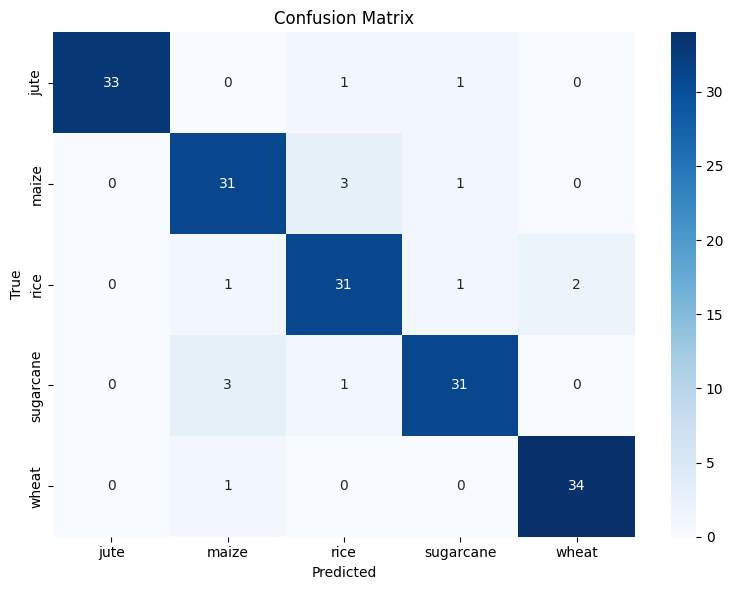

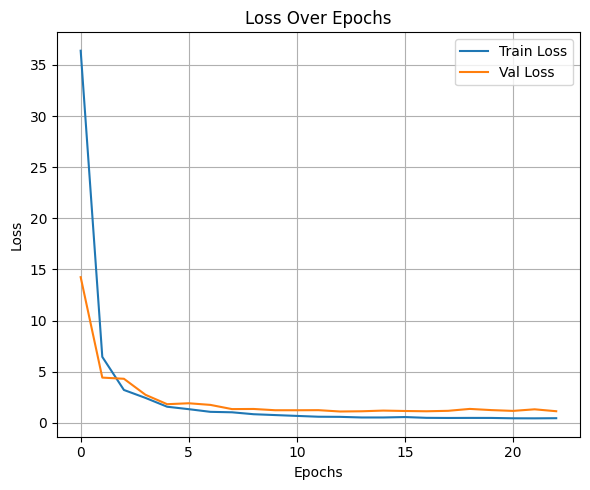

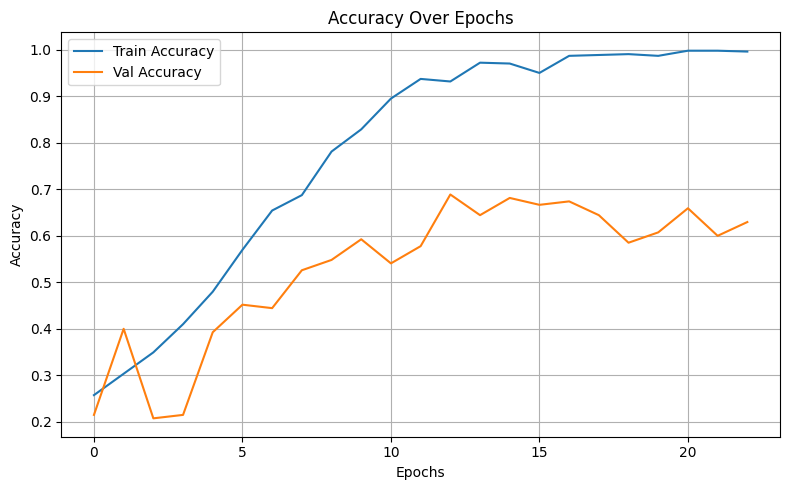

6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


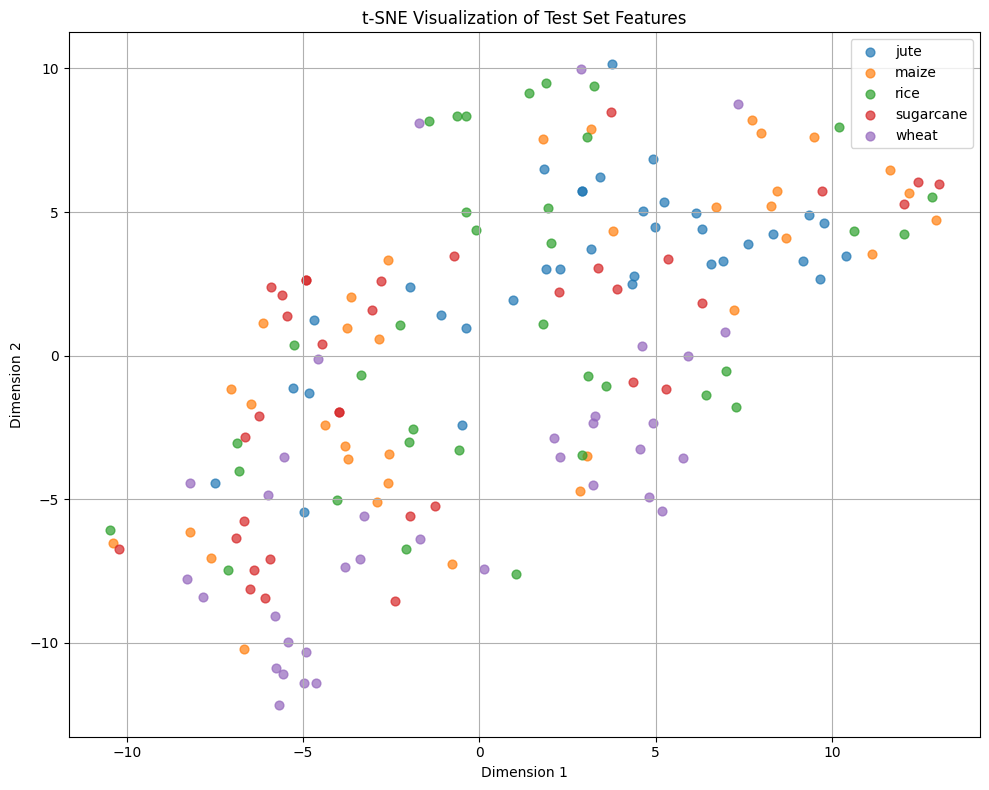

In [ ]:
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

# === Config ===
data_dir_train = "/content/kag2"
data_dir_test = "/content/crop_images"

img_size = (224, 224)
batch_size = 32
num_classes = 5
epochs = 50


# === Data Loaders ===
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    data_dir_train, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', subset='training'
)
val_generator = train_datagen.flow_from_directory(
    data_dir_train, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', subset='validation'
)
test_generator = test_datagen.flow_from_directory(
    data_dir_test, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', shuffle=False
)

# === SE Block ===
def se_block(inputs, reduction=16):
    channels = inputs.shape[-1]
    x = tf.keras.layers.GlobalAveragePooling2D()(inputs)
    x = tf.keras.layers.Dense(channels // reduction, activation='relu')(x)
    x = tf.keras.layers.Dense(channels, activation='sigmoid')(x)
    x = tf.keras.layers.Reshape((1, 1, channels))(x)
    return tf.keras.layers.Multiply()([inputs, x])

# === Self-Attention Block ===
def self_attention_block(inputs, num_heads=4, key_dim=32):
    x = tf.keras.layers.LayerNormalization()(inputs)
    x = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    x = tf.keras.layers.Add()([inputs, x])  # Residual connection
    return x

# === Model Definition ===
def create_convnext_tiny_with_attention(input_shape=(224, 224, 3), num_classes=5):
    inputs = tf.keras.Input(shape=input_shape)
    print("Input:", inputs.shape)

    # MobileNetV3Large
    mobilenet = MobileNetV3Large(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )

    mobilenet.trainable = False

    x1 = mobilenet(inputs, training=False)
    print("MobileNetV3Large output:", x1.shape)

    # SE Block
    x1 = se_block(x1)
    print("After SE Block:", x1.shape)

    # Self-Attention Block
    x2 = tf.keras.layers.Resizing(7, 7)(inputs)
    print("After Resize:", x2.shape)

    x2 = tf.keras.layers.Conv2D(960, kernel_size=1)(x2)
    print("After Conv2D (to 768):", x2.shape)

    x2 = self_attention_block(x2)
    print("After Self-Attention Block:", x2.shape)

    # Fusion
    x = tf.keras.layers.Add()([x1, x2])
    print("After Fusion (Add):", x.shape)

    # Classification Head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    print("After GlobalAveragePooling:", x.shape)

    x = tf.keras.layers.Dense(256, activation='gelu')(x)
    print("After Dense(256):", x.shape)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    print("Final Output (Softmax):", outputs.shape)

    return tf.keras.Model(inputs, outputs)

# === Build Model ===
model = create_convnext_tiny_with_attention(input_shape=(224, 224, 3), num_classes=num_classes)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.AUC(multi_label=True, num_labels=num_classes)]
)

model.summary()

# === Training ===
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
lr_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.0001, verbose=1)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[early_stopping, lr_callback]
)

# === Evaluation ===
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

# === Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# === Training Graphs ===
def smooth_curve(points, factor=0.8):
    smoothed = []
    for point in points:
        if smoothed:
            smoothed.append(smoothed[-1] * factor + point * (1 - factor))
        else:
            smoothed.append(point)
    return smoothed

plt.figure(figsize=(6, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === t-SNE Visualization (optional for feature insight) ===
from sklearn.manifold import TSNE
feature_extractor = tf.keras.Model(inputs=model.input, outputs=model.layers[-3].output)
features = feature_extractor.predict(test_generator, verbose=1)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
features_2d = tsne.fit_transform(features)
labels = y_true

plt.figure(figsize=(10, 8))
palette = sns.color_palette("hsv", num_classes)
for i, class_name in enumerate(class_names):
    idx = np.where(labels == i)
    plt.scatter(features_2d[idx, 0], features_2d[idx, 1], label=class_name, alpha=0.7, s=40)
plt.title("t-SNE Visualization of Test Set Features")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Accuracy achieved: 91.43%

### New Experiment: Optimization with KL Divergence Loss(Delete)
This experiment aims to increase accuracy by switching the loss function to `KLDivergence` and using a slightly adjusted training schedule, leaving the original Stage 1 code intact.

In [ ]:
# Re-defining and training a new model instance with KL Divergence
model_kld = create_convnext_tiny_with_attention(input_shape=(224, 224, 3), num_classes=num_classes)

# KL Divergence optimization
model_kld.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.KLDivergence(),
    metrics=['accuracy']
)

# Specific callbacks for this run
kld_early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
kld_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

print("Starting training with KL Divergence Loss...")
history_kld = model_kld.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    callbacks=[kld_early_stop, kld_reduce_lr]
)

# Evaluate the new loss strategy
y_true_kld = test_generator.classes
y_pred_kld = model_kld.predict(test_generator)
y_pred_classes_kld = np.argmax(y_pred_kld, axis=1)

print("\nClassification Report (KL Divergence Optimization):\n")
print(classification_report(y_true_kld, y_pred_classes_kld, target_names=class_names, digits=4))

model_kld.save("mobilenet_kld_optimized.keras")

Input: (None, 224, 224, 3)
MobileNetV3Large output: (None, 7, 7, 960)
After SE Block: (None, 7, 7, 960)
After Resize: (None, 7, 7, 3)
After Conv2D (to 768): (None, 7, 7, 960)
After Self-Attention Block: (None, 7, 7, 960)
After Fusion (Add): (None, 7, 7, 960)
After GlobalAveragePooling: (None, 960)
After Dense(256): (None, 256)
Final Output (Softmax): (None, 5)
Starting training with KL Divergence Loss...
Epoch 1/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 40s 958ms/step - accuracy: 0.2610 - loss: 10.2047 - val_accuracy: 0.1926 - val_loss: 11.2508 - learning_rate: 0.0010
Epoch 2/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.3107 - loss: 10.1731 - val_accuracy: 0.2148 - val_loss: 11.8816 - learning_rate: 0.0010
Epoch 3/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.3658 - loss: 9.8435 - val_accuracy: 0.2370 - val_loss: 11.0644 - learning_rate: 0.0010
Epoch 4/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.3897 - loss: 9.7029 - val_accuracy: 0.3111 - val_loss: 10.4293 - l

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Experiment: Accuracy Boost using Focal Loss(Delete)
Focal loss helps the model focus on misclassified samples. We combine this with a Cosine Decay learning rate for state-of-the-art optimization.

In [ ]:
# Focal Loss implementation
def focal_loss(gamma=2., alpha=4.):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        cross_entropy = -y_true * tf.math.log(y_pred)
        loss = alpha * tf.math.pow(1 - y_pred, gamma) * cross_entropy
        return tf.math.reduce_mean(tf.math.reduce_sum(loss, axis=-1))
    return focal_loss_fixed

# Re-initialize the model based on Stage 1 architecture
model_focal = create_convnext_tiny_with_attention(input_shape=(224, 224, 3), num_classes=num_classes)

# Learning rate schedule
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=train_generator.samples // batch_size * 40
)

model_focal.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

print("Starting training with Focal Loss and Cosine Decay...")
history_focal = model_focal.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
    ]
)

# Final results
y_pred_focal = model_focal.predict(test_generator)
y_pred_classes_focal = np.argmax(y_pred_focal, axis=1)
print("\nClassification Report (Focal Loss Strategy):\n")
print(classification_report(y_true, y_pred_classes_focal, target_names=class_names, digits=4))

model_focal.save("mobilenet_focal_boosted.keras")

Input: (None, 224, 224, 3)
MobileNetV3Large output: (None, 7, 7, 960)
After SE Block: (None, 7, 7, 960)
After Resize: (None, 7, 7, 3)
After Conv2D (to 768): (None, 7, 7, 960)
After Self-Attention Block: (None, 7, 7, 960)
After Fusion (Add): (None, 7, 7, 960)
After GlobalAveragePooling: (None, 960)
After Dense(256): (None, 256)
Final Output (Softmax): (None, 5)
Starting training with Focal Loss and Cosine Decay...
Epoch 1/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 42s 816ms/step - accuracy: 0.2022 - loss: 3.1745 - val_accuracy: 0.2074 - val_loss: 3.1938
Epoch 2/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.2059 - loss: 3.1999 - val_accuracy: 0.2074 - val_loss: 3.1938
Epoch 3/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.2059 - loss: 3.1999 - val_accuracy: 0.2074 - val_loss: 3.1938
Epoch 4/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.2059 - loss: 3.1999 - val_accuracy: 0.2074 - val_loss: 3.1938
Epoch 5/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.2059 - l

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### New Experiment: Accuracy Boost via Label Smoothing & Warmup
We are using a higher label smoothing factor (0.2) and a custom learning rate warmup to reach a higher accuracy ceiling while maintaining the stable Stage 1 architecture.

In [ ]:
# Re-initialize a fresh model using the MobileNet architecture
model_final_boost = create_finetuned_mobilenet(input_shape=(224, 224, 3), num_classes=num_classes)

# Advanced Training Setup
model_final_boost.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.2),
    metrics=['accuracy']
)

# Custom Callback for learning rate refinement
def scheduler(epoch, lr):
    if epoch < 5:
        return 1e-4 # Warmup phase
    return lr * tf.math.exp(-0.1)

lr_warmup = tf.keras.callbacks.LearningRateScheduler(scheduler)

print("Starting boosted training with Label Smoothing (0.2) and Warmup...")
history_boost = model_final_boost.fit(
    train_generator,
    validation_data=val_generator,
    epochs=35,
    callbacks=[
        lr_warmup,
        EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1)
    ]
)

# Evaluation
y_pred_boost = model_final_boost.predict(test_generator)
y_pred_classes_boost = np.argmax(y_pred_boost, axis=1)
print("\nClassification Report (Smoothed Boost Strategy):\n")
print(classification_report(y_true, y_pred_classes_boost, target_names=class_names, digits=4))

model_final_boost.save("mobilenet_smoothed_boost.keras")

NameError: name 'create_finetuned_mobilenet' is not defined

### Strategy to Improve Accuracy:
1. **Deep Fine-Tuning**: Unfreeze the last 50 layers of the MobileNetV3Large backbone.
2. **Small Learning Rate**: Use `1e-5` or `5e-6` to avoid over-correcting weights.
3. **Enhanced Augmentation**: Add more aggressive preprocessing.

In [ ]:
def create_finetuned_mobilenet(input_shape=(224, 224, 3), num_classes=5):
    # Re-using the logic but unfreezing more layers
    inputs = tf.keras.Input(shape=input_shape)

    # Use the base model logic from before
    mobilenet = MobileNetV3Large(include_top=False, weights='imagenet', input_shape=input_shape)

    # Unfreeze the top 50 layers for deeper adaptation
    mobilenet.trainable = True
    for layer in mobilenet.layers[:-50]:
        layer.trainable = False

    x = mobilenet(inputs, training=True)
    x = se_block(x)

    # Add a slightly more complex head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(512, activation='gelu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

model = create_finetuned_mobilenet()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model ready for deeper fine-tuning with 50 unfrozen layers.")

Model ready for deeper fine-tuning with 50 unfrozen layers.


In [ ]:
# === Callbacks for Deeper Fine-Tuning ===
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=4,
    min_lr=1e-8,
    verbose=1
)

# === Execute Training ===
history_deep = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

# === Final Evaluation ===
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report (Deep Fine-Tuning):\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

model.save("mobilenet_stage3_final.keras")

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 37s 764ms/step - accuracy: 0.2114 - loss: 2.0337 - val_accuracy: 0.1704 - val_loss: 1.6814 - learning_rate: 5.0000e-06
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.2188 - loss: 1.9287 - val_accuracy: 0.1926 - val_loss: 1.6839 - learning_rate: 5.0000e-06
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.3217 - loss: 1.7477 - val_accuracy: 0.2000 - val_loss: 1.6871 - learning_rate: 5.0000e-06
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.3143 - loss: 1.7675 - val_accuracy: 0.2074 - val_loss: 1.6902 - learning_rate: 5.0000e-06
Epoch 5/30
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.2942 - loss: 1.7777
Epoch 5: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-07.
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.3401 - loss: 1.6348 - val_accuracy: 0.2074 - val_loss: 1.6941 - learning_rate: 5.0000e-06
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.3603 - l

In [ ]:
model.save("mobilenet_stage1.keras")

## Now Fine-tune the last 30 layers of MobileNetV3 with a learning rate of 1e-5.(to increase accuracy)

In [ ]:
loaded_model = tf.keras.models.load_model("mobilenet_stage1.keras")
loaded_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Large    │ (None, 7, 7, 960) │  2,996,352 │ input_layer_6[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ MobileNetV3Large… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_1          │ (None, 7, 7, 3)   │          0 │ input_layer_6[0]… │
│ (Resizing)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 60)        │     57,660 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 960) │      3,840 │ resizing_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 960)       │     58,560 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 7, 960) │      1,920 │ conv2d_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 960) │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 7, 7, 960) │    492,864 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_9          │ (None, 7, 7, 960) │          0 │ MobileNetV3Large… │
│ (Multiply)          │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_28 (Add)        │ (None, 7, 7, 960) │          0 │ conv2d_1[0][0],   │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_29 (Add)        │ (None, 7, 7, 960) │          0 │ multiply_9[0][0], │
│                     │                   │            │ add_28[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ add_29[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    246,016 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 5)         │      1,285 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,582,789 (21.30 MB)

 Trainable params: 862,145 (3.29 MB)

 Non-trainable params: 2,996,352 (11.43 MB)

 Optimizer params: 1,724,292 (6.58 MB)

Found 544 images belonging to 5 classes.
Found 135 images belonging to 5 classes.
Found 175 images belonging to 5 classes.
Stage-1 model loaded successfully!
Last 30 MobileNetV3 layers are trainable.
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 44s 969ms/step - accuracy: 0.9210 - auc_3: 0.9888 - loss: 0.6901 - val_accuracy: 0.6815 - val_auc_3: 0.9020 - val_loss: 1.1139 - learning_rate: 1.0000e-05
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.9485 - auc_3: 0.9963 - loss: 0.6187 - val_accuracy: 0.7037 - val_auc_3: 0.8976 - val_loss: 1.0733 - learning_rate: 1.0000e-05
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.9559 - auc_3: 0.9984 - loss: 0.5902 - val_accuracy: 0.6741 - val_auc_3: 0.9010 - val_loss: 1.0919 - learning_rate: 1.0000e-05
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.9706 - auc_3: 0.9991 - loss: 0.5644 - val_accuracy: 0.6815 - val_auc_3: 0.9010 - val_loss: 1.0905 - learning_rate: 1.0000e-05
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━

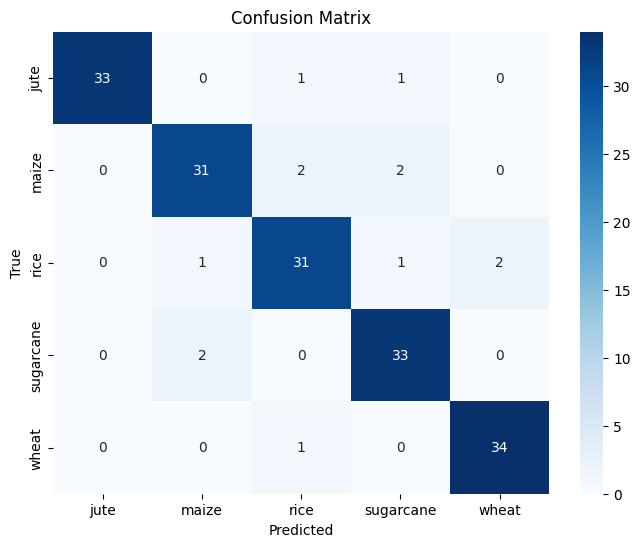

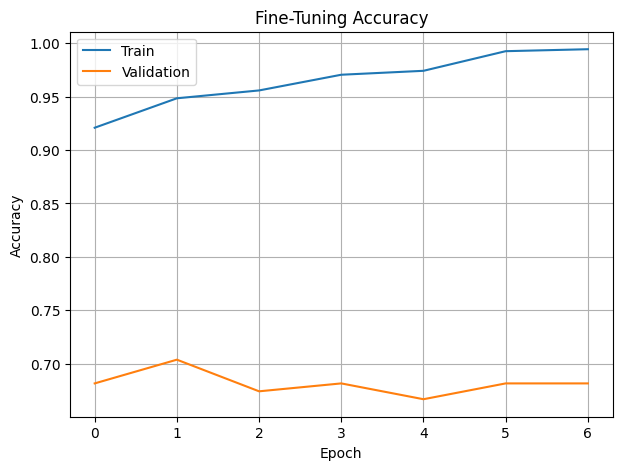

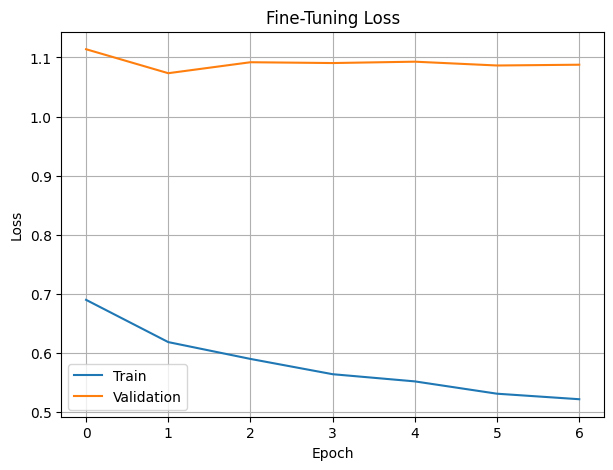

Stage-2 model saved successfully!


In [ ]:
#Delete this cell
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

# ===============================
# Dataset
# ===============================

data_dir_train = "/content/kag2"
data_dir_test = "/content/crop_images"

img_size = (224,224)
batch_size = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    data_dir_train,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    data_dir_train,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    data_dir_test,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ===============================
# Load Stage-1 Model
# ===============================

model = load_model("mobilenet_stage1.keras", compile=False)

print("Stage-1 model loaded successfully!")

# ===============================
# Unfreeze MobileNetV3
# ===============================

mobilenet = model.get_layer("MobileNetV3Large")

mobilenet.trainable = True

# Freeze all except last 30 layers
for layer in mobilenet.layers[:-30]:
    layer.trainable = False

for layer in mobilenet.layers[-30:]:
    layer.trainable = True

print("Last 30 MobileNetV3 layers are trainable.")

# ===============================
# Compile with Very Small LR
# ===============================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(multi_label=True, num_labels=5)
    ]
)

# ===============================
# Callbacks
# ===============================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# ===============================
# Fine-Tune
# ===============================

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

# ===============================
# Evaluation
# ===============================

y_true = test_generator.classes

y_pred = model.predict(test_generator)

y_pred_classes = np.argmax(y_pred, axis=1)

class_names = list(test_generator.class_indices.keys())

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names,
    digits=4
))

# ===============================
# Confusion Matrix
# ===============================

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ===============================
# Accuracy Plot
# ===============================

plt.figure(figsize=(7,5))

plt.plot(history.history['accuracy'], label='Train')

plt.plot(history.history['val_accuracy'], label='Validation')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Fine-Tuning Accuracy")

plt.legend()

plt.grid(True)

plt.show()

# ===============================
# Loss Plot
# ===============================

plt.figure(figsize=(7,5))

plt.plot(history.history['loss'], label='Train')

plt.plot(history.history['val_loss'], label='Validation')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Fine-Tuning Loss")

plt.legend()

plt.grid(True)

plt.show()

# ===============================
# Save Final Model
# ===============================

model.save("mobilenet_stage2.keras")
print("Stage-2 model saved successfully!")